In [1]:
import pandas as pd

In [2]:
# orders.csv
url = "https://drive.google.com/file/d/1lo9OO24val80F5Ml-r2k7rhv5Mq2GjRZ/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders = pd.read_csv(path)

# orderlines.csv
url = "https://drive.google.com/file/d/1mq54Axv3EdHPDQEMgZPrcPpa0pCCaIEt/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines = pd.read_csv(path)


# orderlines_expanded.csv
url = "https://drive.google.com/file/d/1uidji6skTXxityoTI7tdSYwho0rv1mQZ/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_expanded = pd.read_csv(path)


#products.csv
url = "https://drive.google.com/file/d/1sglzr3MyKqbhJxqE4WhWqWfyOLlrf9pO/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products = pd.read_csv(path)

#brands.csv
url = "https://drive.google.com/file/d/1vPx4eDbeCm-gCFcu5bdGjoQ34_FmPui4/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

In [3]:
#Creating Copies to not alter original dataframe
orders_df = orders.copy()
orderlines_df = orderlines.copy()
orderlines_expanded_df = orderlines_expanded.copy()
products_df = products.copy()
brands_df = brands.copy()

In [4]:
#Drop duplicates in every dataframe since we can not use them for analysis

products_df = products_df.drop_duplicates().copy()
orderlines_df = orderlines_df.drop_duplicates().copy()
orders_df = orders_df.drop_duplicates().copy()

In [5]:
#Drop Missing Values since they represent a small amount of data

orders_df = orders_df.dropna(axis=0)
orderlines_df = orderlines_df.dropna(axis=0)
products_df = products_df.dropna(axis=0)

In [6]:
#Transform Dates to correct DateTime Format
orders_df["created_date"] = pd.to_datetime(orders_df["created_date"])
orderlines_df["date"] = pd.to_datetime(orderlines_df["date"])

In [7]:
#Do not drop all of the prices with 2 decimals since they represent a significant amount

def clean_price(price_str):
    if isinstance(price_str, str):
        # Check if it has multiple decimal points
        if price_str.count('.') > 1:
            # For numbers with multiple decimal points, keep only the last decimal point
            parts = price_str.split('.')
            # Join all parts except the last with no separator (removing all dots)
            # Then add the last part with a decimal point
            cleaned_price = ''.join(parts[:-1]) + '.' + parts[-1]
            return cleaned_price

    return price_str

# Apply the cleaning function
orders_df['total_paid'] = orders_df['total_paid'].apply(clean_price)
orderlines_df['unit_price'] = orderlines_df['unit_price'].apply(clean_price)
#products_df['price'] = products_df['price'].apply(clean_price) Due to corruption
#dropping products in products_df due to corruption

products_df["price"] = products_df["price"].astype(str)
products_df = products_df.loc[products_df["price"].str.count(r"\.")< 2].copy()

# Now convert to float
orders_df['total_paid'] = orders_df['total_paid'].astype(float)
orderlines_df['unit_price'] = orderlines_df['unit_price'].astype(float)
products_df['price'] = products_df['price'].astype(float)


In [8]:
#Apply the correction on descriptions in the products dataframe

products_df.loc[products_df['desc'].isna(), 'desc'] = products_df.loc[products_df['desc'].isna(), 'name']

In [ ]:
products_df.head()

,sku,name,desc,price,in_stock,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,"Audio, Peripherals & Accessories"
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,Others
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,Others
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,"Cables, Adapters & Networking"
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,Storage & Memory


In [ ]:
#We can drop the promo_prices from this dataframe, since they are 95% corrupted

products_df = products_df.drop("promo_price", axis=1)

KeyError: "['promo_price'] not found in axis"

In [9]:
#Keep only completed orders for our analysis

orders_df = orders_df.loc[orders_df.state == "Completed"]

In [10]:
#Keep only orders that are present in both dataframes orders, orderlines and products

common_ids = set(orders_df["order_id"]).intersection(orderlines_df["id_order"])

orders_df = orders_df[orders_df["order_id"].isin(common_ids)].copy()
orderlines_df = orderlines_df[orderlines_df["id_order"].isin(common_ids)].copy()

orders_with_removed_products = orderlines_df.loc[~(orderlines_df['sku'].isin(products_df['sku'])),'id_order']
orderlines_df = orderlines_df.loc[~(orderlines_df['id_order'].isin(orders_with_removed_products))].copy()

orders_df = orders_df.loc[~(orders_df['order_id'].isin(orders_with_removed_products))].copy()

orderlines_df['id_order'].nunique(), orders_df["order_id"].nunique()

(44637, 44637)

In [11]:
#Exclude price outliers from our dataset

orderlines_df["unit_price_total"] = orderlines_df["product_quantity"] * orderlines_df["unit_price"]


orderlines_order_ids = orderlines_df.groupby("id_order", as_index=False)["unit_price_total"].sum()

diff_df = orders_df.merge(orderlines_order_ids, left_on="order_id", right_on="id_order")
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]


Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)

IQR = Q3-Q1
Q1 - 1.5*IQR
Q3 + 1.5*IQR

diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= (Q1 - 1.5*IQR))
    &
    (diff_df["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]


normal_diff_list = diff_no_outliers_df["order_id"]

orders_df = orders_df.loc[orders_df["order_id"].isin(normal_diff_list), :]
orderlines_df = orderlines_df.loc[orderlines_df["id_order"].isin(normal_diff_list), :]

orders_df["order_id"].nunique(), orderlines_df["id_order"].nunique()

(44637, 44637)

In [12]:
#Creating product categories

type_to_category = {
    # 1. Apple Computers & Desktops
    "1282":       "Apple Computers & Desktops",  # Type 6
    "5,74E+15":   "Apple Computers & Desktops",  # Type 9
    "1,02E+12":   "Apple Computers & Desktops",  # Type 18
    "2158":       "Apple Computers & Desktops",  # Type 22
    "118692158":  "Apple Computers & Desktops",  # Type 32
    "5,39E+11":   "Apple Computers & Desktops",  # Type 41
    "2,16E+11":   "Apple Computers & Desktops",  # Type 46

    # 2. Apple Mobile Devices
    "11821715":   "Apple Mobile Devices",        # Type 38
    "51601716":   "Apple Mobile Devices",        # Type 45
    "85651716":   "Apple Mobile Devices",        # Type 47

    # 3. Apple Wearables & Accessories
    "11905404":   "Apple Wearables & Accessories", # Type 5
    "2449":       "Apple Wearables & Accessories", # Type 23
    "24885185":   "Apple Wearables & Accessories", # Type 34
    "24895185":   "Apple Wearables & Accessories", # Type 35
    "24215399":   "Apple Wearables & Accessories", # Type 48

    # 4. Cases & Screen Protection
    "11865403":   "Cases & Screen Protection",   # Type 1
    "12635403":   "Cases & Screen Protection",   # Type 7
    "13835403":   "Cases & Screen Protection",   # Type 8
    "13555403":   "Cases & Screen Protection",   # Type 29
    "5,49E+11":   "Cases & Screen Protection",   # Type 42

    # 5. Storage & Memory
    "11935397":   "Storage & Memory",            # Type 4
    "1364":       "Storage & Memory",            # Type 10
    "1433":       "Storage & Memory",            # Type 15
    "12215397":   "Storage & Memory",            # Type 16
    "57445397":   "Storage & Memory",            # Type 20
    "12655397":   "Storage & Memory",            # Type 24
    "42945397":   "Storage & Memory",            # Type 43

    # 6. Cables, Adapters & Networking
    "12175397":   "Cables, Adapters & Networking", # Type 2
    "12585395":   "Cables, Adapters & Networking", # Type 11
    "1325":       "Cables, Adapters & Networking", # Type 13
    "1334":       "Cables, Adapters & Networking", # Type 21
    "12995397":   "Cables, Adapters & Networking", # Type 26
    "1405":       "Cables, Adapters & Networking", # Type 30
    "1230":       "Cables, Adapters & Networking", # Type 31

    # 7. Audio, Peripherals & Accessories
    "1296":       "Audio, Peripherals & Accessories", # Type 12 - Monitors
    "5384":       "Audio, Peripherals & Accessories", # Type 14 - Headphones
    "5398":       "Audio, Peripherals & Accessories", # Type 17 - Wireless Speakers
    "1229":       "Audio, Peripherals & Accessories", # Type 25 - Pens & Pointers
    "1515":       "Audio, Peripherals & Accessories", # Type 27 - External Batteries
    "13615399":   "Audio, Peripherals & Accessories", # Type 28 - Chargers & Docking
    "1216":       "Audio, Peripherals & Accessories", # Type 33 - Adjustable Stands
    "1392":       "Audio, Peripherals & Accessories", # Type 37 - Backpacks & Carry
    "8696":       "Audio, Peripherals & Accessories", # Type 39 - Computer Stands
    "9094":       "Audio, Peripherals & Accessories", # Type 40 - Surveillance Cameras
    "5720":       "Audio, Peripherals & Accessories", # Type 49 - Phone Stands
    "5405":       "Audio, Peripherals & Accessories", # Type 51 - Armbands & Straps
    "13005399":   "Audio, Peripherals & Accessories", # Type 52 - Power Banks & Chargers

    # 8. Repair & Maintenance
    "1,44E+11":   "Repair & Maintenance",        # Type 19
    "21485407":   "Repair & Maintenance",        # Type 36
    "12645406":   "Repair & Maintenance",        # Type 44
    "14305406":   "Repair & Maintenance",        # Type 50

    # 9. Open Items / Resale
    "1298":       "Open Items / Resale",         # Type 3
}

# Apply the mapping, unmatched types fall into "Others"
products_df["category"] = products_df["type"].map(type_to_category).fillna("Others")

products_df.value_counts('category')

,count
category,
Cases & Screen Protection,1817
"Cables, Adapters & Networking",1687
Storage & Memory,1420
"Audio, Peripherals & Accessories",1153
Apple Computers & Desktops,1018
Others,987
Open Items / Resale,818
Apple Wearables & Accessories,745
Repair & Maintenance,316


In [ ]:
products_df.groupby("category").count().nlargest(52, "sku")

,sku,name,desc,price,in_stock,type
category,,,,,,
Cases & Screen Protection,1817,1817,1817,1817,1817,1817
"Cables, Adapters & Networking",1687,1687,1687,1687,1687,1687
Storage & Memory,1420,1420,1420,1420,1420,1420
"Audio, Peripherals & Accessories",1153,1153,1153,1153,1153,1153
Apple Computers & Desktops,1018,1018,1018,1018,1018,1018
Others,987,987,987,987,987,987
Open Items / Resale,818,818,818,818,818,818
Apple Wearables & Accessories,745,745,745,745,745,745
Repair & Maintenance,316,316,316,316,316,316


In [13]:
# Incorporating additional information into orderlines data frame
orderlines_df['short'] = orderlines_df['sku'].str[:3]
orderlines_expanded = (
    orderlines_df
    .merge(products_df,
           on='sku')
    .merge(brands_df,
           on='short')
    .rename(columns={'long':'brand'})
    .drop(columns='short')
)

In [14]:
# Creating composite columns
orderlines_expanded['revenue'] = (
    orderlines_expanded['unit_price'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['discount'] = (
    orderlines_expanded['price'] - orderlines_expanded['unit_price']
)
orderlines_expanded['total_discount'] = (
    orderlines_expanded['discount'] * orderlines_expanded['product_quantity']
)
orderlines_expanded['percentage_discount'] = (
    100 * orderlines_expanded['discount'] / orderlines_expanded['price']
)

In [15]:
#Cleaning discount outliers
orderlines_expanded = orderlines_expanded.loc[orderlines_expanded['percentage_discount'] < 89.9].copy()

In [16]:
products_df.head()

,sku,name,desc,price,in_stock,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,"Audio, Peripherals & Accessories"
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,Others
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,Others
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,"Cables, Adapters & Networking"
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,Storage & Memory


#Orderlines Table containing:
- category
- brand
- revenue
- discount
- total_discount
- percentage_discount
- unit_price & unit_price_total

In [17]:
orderlines_expanded_df.tail()

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total,name,desc,price,in_stock,type,category,brand,revenue,discount,total_discount,percentage_discount
58448,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,9.99,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.0,1,1230,"Cables, Adapters & Networking",Apple,9.99,15.01,15.01,60.04
58449,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.0,1,1230,"Cables, Adapters & Networking",Apple,19.98,15.01,30.02,60.04
58450,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.0,1,1230,"Cables, Adapters & Networking",Apple,19.98,15.01,30.02,60.04
58451,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.0,1,1230,"Cables, Adapters & Networking",Apple,29.97,15.01,45.03,60.04
58452,1649593,527112,0,1,APP0698,9.99,2018-03-14 11:58:13,9.99,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.0,1,1230,"Cables, Adapters & Networking",Apple,9.99,15.01,15.01,60.04


In [18]:
# Group by category types

products_df.value_counts("category")

,count
category,
Cases & Screen Protection,1817
"Cables, Adapters & Networking",1687
Storage & Memory,1420
"Audio, Peripherals & Accessories",1153
Apple Computers & Desktops,1018
Others,987
Open Items / Resale,818
Apple Wearables & Accessories,745
Repair & Maintenance,316


#Top revenue by category - using unit_price_total

In [19]:

#Top revenue by category

top_revenue_category = (
  orderlines_expanded_df
        .groupby("category", as_index=False)["revenue"]
        .sum()
        .sort_values("revenue", ascending=False)
    )

top_revenue_category

,category,revenue
0,Apple Computers & Desktops,5272395.61
7,Others,2779104.70
9,Storage & Memory,2376553.50
3,"Audio, Peripherals & Accessories",1410473.12
4,"Cables, Adapters & Networking",1350696.61
1,Apple Mobile Devices,538346.81
2,Apple Wearables & Accessories,528762.85
5,Cases & Screen Protection,220800.66
6,Open Items / Resale,146719.63
8,Repair & Maintenance,44230.99


#Visual distribution of total revenue by category

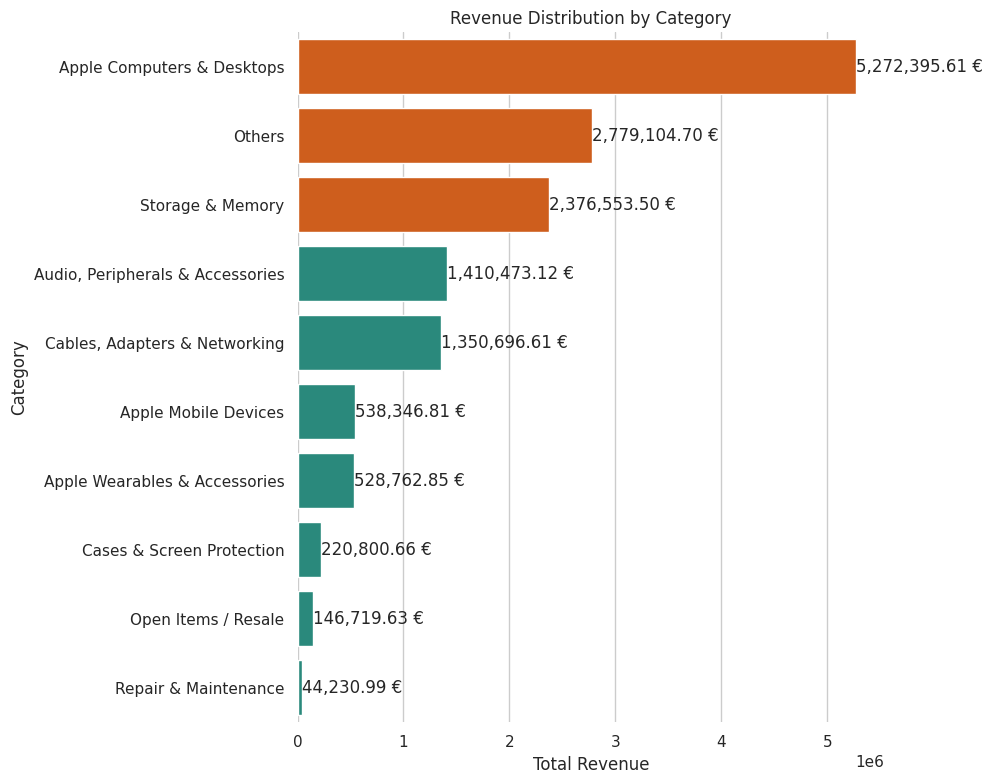

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting seaborn theme
sns.set_theme(style="whitegrid")

# Copy dataframe for safety
top_revenue_category_df = top_revenue_category.copy()

# Color palette (top 3 highlighted)
colors = ['#EB5600' if i < 3 else '#1A9988' #'#D3D3D3'
          for i in range(len(top_revenue_category_df))]

plt.figure(figsize=(10, 8))

# Seaborn barplot
sns.barplot(
    data=top_revenue_category_df,
    x="revenue",
    y="category",
    hue="category",
    palette=colors
)

plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.title("Revenue Distribution by Category")

# Add revenue labels
for i, value in enumerate(top_revenue_category_df["revenue"]):
    plt.text(value, i, f"{value:,.2f} €", va='center')

plt.tight_layout()

sns.despine(left=True, bottom=True) # "sns.despine()" removes chart borders
plt.show();